### Notebook adapted for 5-class (0–4) classification
- Set num_classes = 5 where applicable
- Switched multiclass (0–4) losses/activations to multi-class (e.g., sigmoid→softmax, binary_crossentropy→sparse_categorical_crossentropy)
- Replaced threshold-based predictions with argmax
- Ensured stratified splits for y (0–4)
- Updated evaluation to use classification_report and a 5×5 confusion matrix
- Kept DBSCAN/feature steps intact unless explicitly multiclass (0–4)-only

# IDRiD — multiclass (0–4) DR Classifier (No DR=0, DR≥1) with **DBSCAN** Pseudo-Labels, Circular Crop, CLAHE & HPO

**Generated:** 2025-08-20

This notebook switches the pseudo-labeling stage to **DBSCAN** instead of k-means, for the multiclass (0–4) task:
- Map labels to **0 if diagnosis==0**, else **1** (DR present)
- Extract EfficientNet embeddings → scale + PCA → **DBSCAN** on train set
- Map DBSCAN clusters to multiclass (0–4) via **majority vote** (noise gets nearest centroid label)
- Use these pseudo-labels to pretrain; then **fine-tune** with true labels using a small HPO

**Data assumptions**:
- CSV: `/kaggle/input/idrid-dataset/idrid_labels.csv`
- Images: `/kaggle/input/idrid-dataset/Imagenes/Imagenes/{id_code}.jpg`


## 1. Setup, Config & Reproducibility

In [ ]:

import os, random, warnings, copy, math, time
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (classification_report, confusion_matrix, f1_score, accuracy_score,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestCentroid
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    import cv2
    CV2_AVAILABLE = True
except Exception:
    CV2_AVAILABLE = False

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
seed_everything()

# Preprocessing toggles
ENABLE_CIRCULAR_CROP = True
ENABLE_CLAHE = True
CLAHE_CLIP = 2.0
CLAHE_GRID = 8

# DBSCAN param grid (in PCA space after StandardScaler)
EPS_GRID = [0.5, 0.8, 1.0, 1.2, 1.5]
MIN_SAMPLES_GRID = [3, 5, 10]

# Training config
PRETRAIN_EPOCHS = 5
SWEEP_LR = [1e-4, 3e-4]
SWEEP_WD = [1e-5, 1e-4]
SWEEP_DROPOUT = [0.2, 0.4]
SWEEP_EPOCHS = 6
FINAL_EPOCHS = 15
BATCH_SIZE = 32


## 2. Load CSV, Map to multiclass (0–4) Labels & Build Image Paths

In [ ]:
CSV_PATH = "/kaggle/input/idrid-dataset/idrid_labels.csv"
IMG_DIR  = "/kaggle/input/idrid-dataset/Imagenes/Imagenes"

# Robust CSV loading and column detection
df = pd.read_csv(CSV_PATH)
# normalize column names
norm_map = {c.lower().strip(): c for c in df.columns}
# try common variants
id_candidates  = ["id_code","image","image_id","id","image name","image_name"]
lab_candidates = ["diagnosis","level","dr_level","dr_grade","dr","retinopathy","retinopathy grade"]

id_col  = next((norm_map[k] for k in id_candidates  if k in norm_map), None)
lab_col = next((norm_map[k] for k in lab_candidates if k in norm_map), None)
if id_col is None or lab_col is None:
    raise ValueError(f"Could not find id/diagnosis columns in {CSV_PATH}. Columns: {list(df.columns)}")

df = df[[id_col, lab_col]].copy()
df.columns = ["id_code", "diagnosis"]
df["diagnosis"] = df["diagnosis"].astype(int)
df["label"] = (df["diagnosis"] > 0).astype(int)

def build_img_path(id_code):
    base = Path(IMG_DIR) / f"{id_code}"
    for ext in [".jpg", ".JPG", ".png", ".jpeg", ".JPEG"]:
        p = base.with_suffix(ext)
        if p.exists():
            return str(p)
    return str(base.with_suffix(".jpg"))  # fallback

df["image_path"] = df["id_code"].apply(build_img_path)
print(df.head())
print("\nBinary class distribution:\n", df["label"].value_counts().sort_index())

## 3. Stratified 70/15/15 Split (on multiclass (0–4) Label)

In [ ]:

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(sss1.split(df, df["label"]))
train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df  = df.iloc[temp_idx].reset_index(drop=True)

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(sss2.split(temp_df, temp_df["label"]))
val_df  = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

for name, d in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name}: {len(d)} images | binary class counts:")
    print(d["label"].value_counts().sort_index(), "\n")


## 4. Advanced Preprocessing — Circular Crop & CLAHE

In [ ]:

import numpy as np
from PIL import Image

def center_square_crop(np_img):
    h, w = np_img.shape[:2]
    s = min(h, w)
    y0 = (h - s) // 2
    x0 = (w - s) // 2
    return np_img[y0:y0+s, x0:x0+s]

def circular_crop(np_img, margin=0.02):
    sq = center_square_crop(np_img)
    h, w = sq.shape[:2]
    r = int(0.5 * min(h, w) * (1.0 - margin))
    cy, cx = h // 2, w // 2
    Y, X = np.ogrid[:h, :w]
    mask = (X - cx)**2 + (Y - cy)**2 <= r*r
    out = np.zeros_like(sq)
    out[mask] = sq[mask]
    return out

def apply_clahe_green(np_img, clip=2.0, grid=8):
    try:
        import cv2
        bgr = cv2.cvtColor(np_img, cv2.COLOR_RGB2BGR)
        g = bgr[:,:,1]
        clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=(int(grid), int(grid)))
        g_eq = clahe.apply(g)
        bgr[:,:,1] = g_eq
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        return rgb
    except Exception:
        g = np_img[:,:,1].astype(np.float32)
        g = (g - g.min()) / max(1e-6, (g.max()-g.min()))
        g = (g * 255.0).astype(np.uint8)
        np_img2 = np_img.copy()
        np_img2[:,:,1] = g
        return np_img2

class Preprocessor:
    def __init__(self, circ=True, clahe=True, clip=2.0, grid=8):
        self.circ = circ
        self.clahe = clahe
        self.clip = clip
        self.grid = grid
    def __call__(self, pil_img):
        np_img = np.array(pil_img)
        if self.circ:
            np_img = circular_crop(np_img, margin=0.02)
        if self.clahe:
            np_img = apply_clahe_green(np_img, clip=self.clip, grid=self.grid)
        return Image.fromarray(np_img)

preproc = Preprocessor(ENABLE_CIRCULAR_CROP, ENABLE_CLAHE, CLAHE_CLIP, CLAHE_GRID)


## 5. Dataset, Transforms & Loaders

In [ ]:

from torchvision import transforms
from torch.utils.data import DataLoader, WeightedRandomSampler

train_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

eval_tfms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class IDRiDDataset(Dataset):
    def __init__(self, df, transform, preproc=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.preproc = preproc
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.preproc is not None:
            img = self.preproc(img)
        img = self.transform(img)
        label = int(row["label"])   # binary
        return img, label, row["id_code"]

train_ds = IDRiDDataset(train_df, train_tfms, preproc=preproc)
val_ds   = IDRiDDataset(val_df,   eval_tfms, preproc=preproc)
test_ds  = IDRiDDataset(test_df,  eval_tfms, preproc=preproc)

def make_loader(ds, shuffle, weighted=False):
    if not weighted:
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2, pin_memory=True)
    labels = [lab for _, lab, _ in ds]
    class_counts = np.bincount(labels, minlength=2)
    class_weights = 1.0 / (class_counts + 1e-6)
    sample_weights = [class_weights[lab] for lab in labels]
    sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return DataLoader(ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)

train_loader = make_loader(train_ds, shuffle=True, weighted=True)
val_loader   = make_loader(val_ds,   shuffle=False)
test_loader  = make_loader(test_ds,  shuffle=False)


## 6. EfficientNet Backbone & Embeddings

In [ ]:

try:
    from torchvision.models import EfficientNet_B0_Weights
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    backbone = models.efficientnet_b0(weights=weights)
except Exception:
    backbone = models.efficientnet_b0(pretrained=True)

embed_net = copy.deepcopy(backbone)
embed_net.classifier = nn.Identity()
embed_net = embed_net.to(device)
embed_net.eval()

@torch.no_grad()
def extract_embeddings(dloader):
    feats, lbls, ids = [], [], []
    for x, y, idc in dloader:
        x = x.to(device)
        f = embed_net(x)            # [B, 1280]
        feats.append(f.cpu().numpy())
        lbls.append(y.numpy())
        ids.extend(list(idc))
    return np.concatenate(feats), np.concatenate(lbls), ids

print("Extracting embeddings (train/val/test)...")
train_feats, train_lbls, train_ids = extract_embeddings(make_loader(train_ds, shuffle=False))
val_feats,   val_lbls,   val_ids   = extract_embeddings(val_loader)
test_feats,  test_lbls,  test_ids  = extract_embeddings(test_loader)
print("Shapes:", train_feats.shape, val_feats.shape, test_feats.shape)


## 7. DBSCAN on Train Embeddings (Scale→PCA→DBSCAN) + Param Search

In [ ]:

# Scale and reduce
scaler = StandardScaler()
pca = PCA(n_components=min(50, train_feats.shape[1]))
train_red = pca.fit_transform(scaler.fit_transform(train_feats))
val_red   = pca.transform(scaler.transform(val_feats))

def fit_dbscan_and_map(train_red, y_train, eps, min_samples):
    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    cluster_ids = db.fit_predict(train_red)  # -1 noise or 0..K-1 clusters
    unique = np.unique(cluster_ids)
    # If all noise or single cluster, return None
    if len(unique) <= 1 and (unique[0] == -1 or unique[0] == 0):
        return None, None, None, None
    # Build majority-vote mapping from cluster -> binary label
    mapping = {}
    centroids = {}
    for cid in unique:
        idx = np.where(cluster_ids == cid)[0]
        if len(idx) == 0: 
            continue
        if cid == -1:
            continue  # handle later
        maj = int(np.round(y_train[idx].mean()))  # majority of 0/1
        mapping[cid] = maj
        centroids[cid] = train_red[idx].mean(axis=0)
    if len(centroids)==0:
        return None, None, None, None
    # Nearest-centroid classifier for assigning labels to any point (incl. noise)
    clf = NearestCentroid()
    Xc = np.stack(list(centroids.values()))
    yc = np.array([mapping[k] for k in centroids.keys()])
    clf.fit(Xc, yc)
    return cluster_ids, mapping, centroids, clf

def predict_with_centroids(clf, centroids, X):
    # nearest centroid label
    return clf.predict(X)

best = {"f1": -1, "eps": None, "min_samples": None, "mapping": None, "centroids": None, "clf": None, "train_clusters": None}
for eps in EPS_GRID:
    for ms in MIN_SAMPLES_GRID:
        out = fit_dbscan_and_map(train_red, train_lbls, eps, ms)
        if out[0] is None:
            continue
        tr_clusters, mapping, centroids, clf = out
        val_pred = predict_with_centroids(clf, centroids, val_red)
        f1b = f1_score(val_lbls, val_pred, average='macro')
        print(f"eps={eps:.2f} ms={ms} -> val F1={f1b:.4f}")
        if f1b > best["f1"]:
            best.update({"f1": f1b, "eps": eps, "min_samples": ms, "mapping": mapping, "centroids": centroids, "clf": clf, "train_clusters": tr_clusters})

print("\nBest DBSCAN:", {k:best[k] for k in ["eps","min_samples","f1"]})


## 8. Visualize DBSCAN Clusters (Train) & Build Pseudo-Labels

In [ ]:
# --- Quick fix for: AttributeError: 'NoneType' object has no attribute 'predict' ---
# Requires variables from earlier cells: train_red, val_red, train_lbls, val_lbls, SEED,
# and the helper 'fit_dbscan_and_map' defined in the DBSCAN search cell.

import numpy as np
from sklearn.neighbors import NearestNeighbors, NearestCentroid
from sklearn.cluster import KMeans

def majority_map(clusters, emb, y):
    mapping, centroids = {}, {}
    for cid in np.unique(clusters):
        idx = np.where(clusters == cid)[0]
        if len(idx) == 0: 
            continue
        maj = int(np.round(y[idx].mean()))   # majority vote for binary labels
        mapping[cid] = maj
        centroids[cid] = emb[idx].mean(axis=0)
    clf = NearestCentroid()
    Xc = np.stack(list(centroids.values()))
    yc = np.array([mapping[c] for c in centroids.keys()])
    clf.fit(Xc, yc)
    return mapping, centroids, clf

if best.get("clf", None) is None:
    print("DBSCAN didn't produce usable clusters. Trying an automatic eps/min_samples heuristic...")
    # Heuristic eps: 90th percentile of 5-NN distances in PCA space
    k = 5
    nbrs = NearestNeighbors(n_neighbors=k).fit(train_red)
    distances, _ = nbrs.kneighbors(train_red)
    kdist = np.sort(distances[:, -1])
    eps_auto = float(np.clip(np.percentile(kdist, 90), 0.1, 3.0))
    ms_auto = 5

    out = fit_dbscan_and_map(train_red, train_lbls, eps_auto, ms_auto)
    if out[0] is not None:
        tr_clusters, mapping, centroids, clf = out
        best.update({
            "f1": None,  # unknown for this heuristic path
            "eps": eps_auto, "min_samples": ms_auto,
            "mapping": mapping, "centroids": centroids,
            "clf": clf, "train_clusters": tr_clusters
        })
        print(f"✅ Heuristic DBSCAN worked: eps={eps_auto:.3f}, min_samples={ms_auto}")
    else:
        print("Heuristic DBSCAN also failed. Falling back to K-Means(2) pseudo-labels.")
        km = KMeans(n_clusters=2, random_state=SEED, n_init=10)
        tr_clusters = km.fit_predict(train_red)
        mapping, centroids, clf = majority_map(tr_clusters, train_red, train_lbls)
        best.update({
            "f1": None,
            "eps": None, "min_samples": None,
            "mapping": mapping, "centroids": centroids,
            "clf": clf, "train_clusters": tr_clusters
        })
        print("✅ K-Means fallback ready.")

# Now you can safely build pseudo labels:
pseudo_train_labels = best["clf"].predict(train_red)
print("Pseudo label counts:", np.bincount(pseudo_train_labels))
print("Agreement pseudo vs true (train):", (pseudo_train_labels == train_lbls).mean())

In [ ]:

# 2D viz via PCA components 1&2 (already PCA-reduced)
plt.figure(figsize=(7,6))
plt.scatter(train_red[:,0], train_red[:,1], c=best["train_clusters"], alpha=0.7)
plt.title("Train PCA (2D) colored by DBSCAN cluster id (noise=-1)")
plt.show()

# Build pseudo labels for the **train** set using nearest centroid labels
pseudo_train_labels = best["clf"].predict(train_red)  # mapped 0/1 for all points
print("Pseudo label counts:", np.bincount(pseudo_train_labels))

# For info: agreement with ground truth on train
train_agree = (pseudo_train_labels == train_lbls).mean()
print(f"Agreement pseudo vs true on train: {train_agree:.4f}")


## 9. Stage A — Pretrain with Pseudo-Labels (multiclass (0–4))

In [ ]:

def make_model(num_out, dropout_p=0.2):
    model = copy.deepcopy(backbone)
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p, inplace=True),
        nn.Linear(in_features, num_out)
    )
    return model.to(device)

cluster_model = make_model(5, dropout_p=0.2)  # binary head

class PseudoLabelDataset(Dataset):
    def __init__(self, base_ds, pseudo_labels):
        self.base_ds = base_ds
        self.pseudo_labels = pseudo_labels
    def __len__(self):
        return len(self.base_ds)
    def __getitem__(self, idx):
        x, _, idc = self.base_ds[idx]
        return x, int(self.pseudo_labels[idx]), idc

pseudo_train_ds = PseudoLabelDataset(train_ds, pseudo_train_labels)
pseudo_train_loader = DataLoader(pseudo_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

def train_one_epoch(model, loader, optim, criterion):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        optim.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optim.step()
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    for x, y, _ in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss/total, total_correct/total

optim_pre = torch.optim.AdamW(cluster_model.parameters(), lr=3e-4, weight_decay=1e-4)
criterion_pre = nn.CrossEntropyLoss()

hist_pre = {"train_loss":[], "train_acc":[]}
for epoch in range(1, PRETRAIN_EPOCHS+1):
    tr_loss, tr_acc = train_one_epoch(cluster_model, pseudo_train_loader, optim_pre, criterion_pre)
    hist_pre["train_loss"].append(tr_loss); hist_pre["train_acc"].append(tr_acc)
    print(f"[Pretrain] {epoch:02d}/{PRETRAIN_EPOCHS} | train_loss={tr_loss:.4f} acc={tr_acc:.4f}")

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(hist_pre["train_loss"], label="train"); plt.title("Pretraining Loss"); plt.legend()
plt.subplot(1,2,2); plt.plot(hist_pre["train_acc"], label="train"); plt.title("Pretraining Accuracy"); plt.legend()
plt.show()


## 10. Stage B — Hyperparameter Sweep then Final Fine-Tuning (multiclass (0–4))

In [ ]:
# # --- Multiclass (0–4) fine-tuning — fixed weights, metrics, and reports ---
# import copy
# import torch
# import torch.nn as nn
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.metrics import (
#     accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
# )

# # Fallback device (if not defined earlier)
# try:
#     device
# except NameError:
#     device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# NUM_CLASSES = 5  # multiclass (0..4)

# # Robust class weights from the training loader (always length = NUM_CLASSES)
# @torch.no_grad()
# def get_class_weights_from_loader(loader, num_classes=NUM_CLASSES, eps=1e-6, normalize=True):
#     counts = torch.zeros(num_classes, dtype=torch.float64)
#     for _, y, _ in loader:
#         y = y.flatten().to("cpu")
#         counts += torch.bincount(y, minlength=num_classes).to(torch.float64)
#     counts = counts + eps
#     inv = 1.0 / counts
#     if normalize:
#         inv = inv * (counts.sum() / (num_classes * counts))
#     return inv.to(torch.float32)

# def make_finetune_model(from_model, num_out, dropout_p):
#     m = copy.deepcopy(from_model)
#     # Assumes a classifier with last Linear at m.classifier[-1]
#     in_features = m.classifier[-1].in_features
#     m.classifier = nn.Sequential(
#         nn.Dropout(p=dropout_p, inplace=True),
#         nn.Linear(in_features, num_out)
#     )
#     return m.to(device)

# @torch.no_grad()
# def evaluate_metrics(model, loader):
#     model.eval()
#     all_logits, all_y = [], []
#     for x, y, _ in loader:
#         x = x.to(device)
#         logits = model(x)
#         all_logits.append(logits.cpu())
#         all_y.append(y)
#     all_logits = torch.cat(all_logits).numpy()
#     all_y = torch.cat(all_y).numpy()
#     preds = all_logits.argmax(1)
#     acc = accuracy_score(all_y, preds)
#     f1m = f1_score(all_y, preds, average='macro')
#     return acc, f1m

# # Class weights for imbalance (NUM_CLASSES length)
# class_weights = get_class_weights_from_loader(train_loader, NUM_CLASSES).to(device)

# results = []
# best = {"f1": -1.0, "state": None, "hp": None}

# for lr in SWEEP_LR:
#     for wd in SWEEP_WD:
#         for dp in SWEEP_DROPOUT:
#             print(f"\n=== SWEEP: lr={lr}, wd={wd}, dropout={dp} ===")
#             model = make_finetune_model(cluster_model, NUM_CLASSES, dropout_p=dp)
#             criterion = nn.CrossEntropyLoss(weight=class_weights)
#             optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
#             scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, SWEEP_EPOCHS))

#             for ep in range(1, SWEEP_EPOCHS + 1):
#                 model.train()
#                 for x, y, _ in train_loader:
#                     x, y = x.to(device), y.to(device)
#                     optimizer.zero_grad()
#                     logits = model(x)
#                     loss = criterion(logits, y)
#                     loss.backward()
#                     optimizer.step()
#                 scheduler.step()

#             val_acc, val_f1 = evaluate_metrics(model, val_loader)
#             results.append({"lr": lr, "wd": wd, "dropout": dp, "val_f1": val_f1, "val_acc": val_acc})
#             print(f"Validation F1 (macro)={val_f1:.4f} | Acc={val_acc:.4f}")
#             if val_f1 > best["f1"]:
#                 best["f1"] = val_f1
#                 best["state"] = copy.deepcopy(model.state_dict())
#                 best["hp"] = {"lr": lr, "wd": wd, "dropout": dp}

# res_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
# display(res_df)

# plt.figure(figsize=(8,4))
# plt.bar(range(len(res_df)), res_df["val_f1"].values)
# plt.title("Validation F1 (macro) by Hyperparameter Combo (sorted)")
# plt.xlabel("Combo rank"); plt.ylabel("F1 (macro)")
# plt.tight_layout(); plt.show()

# print("Best HP:", best["hp"], "Best Val F1 (macro):", best["f1"])

# # Final training with best HP
# hp = best["hp"]
# finetune_model = make_finetune_model(cluster_model, NUM_CLASSES, dropout_p=hp["dropout"])
# finetune_model.load_state_dict(best["state"])  # warm start (optional)
# criterion_sup = nn.CrossEntropyLoss(weight=class_weights)
# optimizer = torch.optim.AdamW(finetune_model.parameters(), lr=hp["lr"], weight_decay=hp["wd"])
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, FINAL_EPOCHS))

# @torch.no_grad()
# def evaluate_full(model, loader):
#     model.eval()
#     all_logits, all_y, all_ids = [], [], []
#     for x, y, ids in loader:
#         x = x.to(device)
#         logits = model(x)
#         all_logits.append(logits.cpu())
#         all_y.append(y)
#         all_ids += list(ids)
#     all_logits = torch.cat(all_logits).numpy()
#     all_y = torch.cat(all_y).numpy()
#     preds = all_logits.argmax(1)
#     acc = accuracy_score(all_y, preds)
#     f1m = f1_score(all_y, preds, average='macro')
#     return acc, f1m, preds, all_logits, all_y, all_ids

# hist = {"train_loss": [], "val_f1": []}
# best_val_f1, best_state = -1.0, None

# for epoch in range(1, FINAL_EPOCHS + 1):
#     finetune_model.train()
#     total_loss, total = 0.0, 0
#     for x, y, _ in train_loader:
#         x, y = x.to(device), y.to(device)
#         optimizer.zero_grad()
#         logits = finetune_model(x)
#         loss = criterion_sup(logits, y)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item() * x.size(0)
#         total += x.size(0)
#     scheduler.step()

#     val_acc, val_f1, _, _, _, _ = evaluate_full(finetune_model, val_loader)
#     tr_loss = total_loss / max(1, total)
#     hist["train_loss"].append(tr_loss); hist["val_f1"].append(val_f1)
#     print(f"[Final FT] {epoch:02d}/{FINAL_EPOCHS} | train_loss={tr_loss:.4f} | val_f1={val_f1:.4f} (acc={val_acc:.4f})")
#     if val_f1 > best_val_f1:
#         best_val_f1 = val_f1
#         best_state = copy.deepcopy(finetune_model.state_dict())

# if best_state is not None:
#     finetune_model.load_state_dict(best_state)

# plt.figure(figsize=(8,4))
# plt.plot(hist["train_loss"], label="train_loss")
# plt.plot(hist["val_f1"], label="val_f1 (macro)")
# plt.title("Fine-tuning Progress (Best HP) — Multiclass (0–4)")
# plt.legend(); plt.tight_layout(); plt.show()

# # Test
# test_acc, test_f1, test_preds, test_logits, test_y, test_id = evaluate_full(finetune_model, test_loader)
# print(f"Test Accuracy: {test_acc:.4f} | Test F1 (macro): {test_f1:.4f}")

# print("\nClassification Report (Test, 5 classes):")
# target_names = ['No DR (0)','Mild (1)','Moderate (2)','Severe (3)','Proliferative (4)']
# print(classification_report(test_y, test_preds, target_names=target_names, digits=4))

# cm = confusion_matrix(test_y, test_preds, labels=list(range(NUM_CLASSES)))
# plt.figure(figsize=(6,5))
# plt.imshow(cm, interpolation='nearest')
# plt.title("Confusion Matrix — Test (5 classes)")
# plt.colorbar()
# plt.xticks(list(range(NUM_CLASSES)), list(range(NUM_CLASSES)))
# plt.yticks(list(range(NUM_CLASSES)), list(range(NUM_CLASSES)))
# plt.xlabel("Predicted"); plt.ylabel("True")
# for i in range(cm.shape[0]):
#     for j in range(cm.shape[1]):
#         plt.text(j, i, str(cm[i, j]), ha="center", va="center")
# plt.tight_layout(); plt.show()

# # (Optional) Macro ROC-AUC (OvR) for multiclass using probabilities
# with torch.no_grad():
#     probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

# try:
#     auc_macro_ovr = roc_auc_score(test_y, probs, multi_class='ovr', average='macro')
#     print(f"Macro ROC-AUC (OvR): {auc_macro_ovr:.4f}")
# except ValueError as e:
#     print("ROC-AUC not defined (likely only one class present in y_test).", e)

Fix

In [25]:
# --- Multiclass (0–4) fine-tuning — FIXED DATA LOADERS, weights, metrics, and reports ---
import copy
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, roc_auc_score
)
from torch.utils.data import Dataset, DataLoader # Ensure Dataset is imported here

# Fallback device (if not defined earlier)
try:
    device
except NameError:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_CLASSES = 5  # multiclass (0..4)

# FIX 1: Create a new Dataset class to fetch the multiclass 'diagnosis' labels (0-4)
class IDRiDMulticlassDataset(Dataset):
    def __init__(self, df, transform, preproc=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.preproc = preproc
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        if self.preproc is not None:
            img = self.preproc(img)
        img = self.transform(img)
        # Return the multiclass 'diagnosis' label instead of the binary 'label'
        label = int(row["diagnosis"])
        return img, label, row["id_code"]

# FIX 2: Create new multiclass datasets and dataloaders
train_mc_ds = IDRiDMulticlassDataset(train_df, train_tfms, preproc=preproc)
val_mc_ds   = IDRiDMulticlassDataset(val_df,   eval_tfms,  preproc=preproc)
test_mc_ds  = IDRiDMulticlassDataset(test_df,  eval_tfms,  preproc=preproc)

train_mc_loader = DataLoader(train_mc_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_mc_loader   = DataLoader(val_mc_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_mc_loader  = DataLoader(test_mc_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# Robust class weights from the training loader (always length = NUM_CLASSES)
@torch.no_grad()
def get_class_weights_from_loader(loader, num_classes=NUM_CLASSES, eps=1e-6, normalize=True):
    counts = torch.zeros(num_classes, dtype=torch.float64)
    for _, y, _ in loader:
        y = y.flatten().to("cpu")
        counts += torch.bincount(y, minlength=num_classes).to(torch.float64)
    counts = counts + eps
    inv = 1.0 / counts
    if normalize:
        # A more standard normalization for class weights
        inv /= inv.sum()
    return inv.to(torch.float32)

def make_finetune_model(from_model, num_out, dropout_p):
    m = copy.deepcopy(from_model)
    in_features = m.classifier[-1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p, inplace=True),
        nn.Linear(in_features, num_out)
    )
    return m.to(device)

@torch.no_grad()
def evaluate_metrics(model, loader):
    model.eval()
    all_logits, all_y = [], []
    for x, y, _ in loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_y.append(y)
    all_logits = torch.cat(all_logits).numpy()
    all_y = torch.cat(all_y).numpy()
    preds = all_logits.argmax(1)
    acc = accuracy_score(all_y, preds)
    f1m = f1_score(all_y, preds, average='macro')
    return acc, f1m


=== SWEEP: lr=0.0001, wd=1e-05, dropout=0.2 ===
Validation F1 (macro)=0.4480 | Acc=0.4559

=== SWEEP: lr=0.0001, wd=1e-05, dropout=0.4 ===
Validation F1 (macro)=0.4423 | Acc=0.4706

=== SWEEP: lr=0.0001, wd=0.0001, dropout=0.2 ===
Validation F1 (macro)=0.4592 | Acc=0.4853

=== SWEEP: lr=0.0001, wd=0.0001, dropout=0.4 ===
Validation F1 (macro)=0.5072 | Acc=0.5294

=== SWEEP: lr=0.0003, wd=1e-05, dropout=0.2 ===
Validation F1 (macro)=0.5789 | Acc=0.6176

=== SWEEP: lr=0.0003, wd=1e-05, dropout=0.4 ===
Validation F1 (macro)=0.5273 | Acc=0.5441

=== SWEEP: lr=0.0003, wd=0.0001, dropout=0.2 ===
Validation F1 (macro)=0.5399 | Acc=0.5588

=== SWEEP: lr=0.0003, wd=0.0001, dropout=0.4 ===
Validation F1 (macro)=0.5142 | Acc=0.5147


,lr,wd,dropout,val_f1,val_acc
0,0.0003,0.00001,0.2,0.578947,0.617647
1,0.0003,0.00010,0.2,0.539874,0.558824
2,0.0003,0.00001,0.4,0.527339,0.544118
3,0.0003,0.00010,0.4,0.514229,0.514706
4,0.0001,0.00010,0.4,0.507185,0.529412
5,0.0001,0.00010,0.2,0.459224,0.485294
6,0.0001,0.00001,0.2,0.448031,0.455882
7,0.0001,0.00001,0.4,0.442350,0.470588


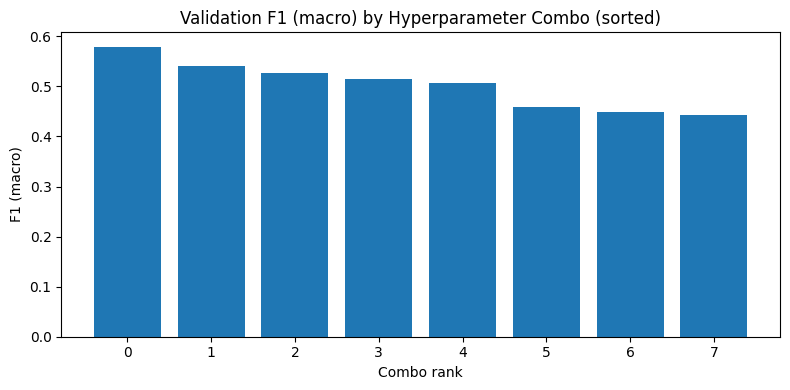

Best HP: {'lr': 0.0003, 'wd': 1e-05, 'dropout': 0.2} Best Val F1 (macro): 0.5789473684210527


In [26]:
# FIX 3: Calculate class weights using the NEW multiclass loader
class_weights = get_class_weights_from_loader(train_mc_loader, NUM_CLASSES).to(device)

results = []
best = {"f1": -1.0, "state": None, "hp": None}

for lr in SWEEP_LR:
    for wd in SWEEP_WD:
        for dp in SWEEP_DROPOUT:
            print(f"\n=== SWEEP: lr={lr}, wd={wd}, dropout={dp} ===")
            model = make_finetune_model(cluster_model, NUM_CLASSES, dropout_p=dp)
            criterion = nn.CrossEntropyLoss(weight=class_weights)
            optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, SWEEP_EPOCHS))

            for ep in range(1, SWEEP_EPOCHS + 1):
                model.train()
                # FIX 4: Use the new multiclass training loader
                for x, y, _ in train_mc_loader:
                    x, y = x.to(device), y.to(device)
                    optimizer.zero_grad()
                    logits = model(x)
                    loss = criterion(logits, y)
                    loss.backward()
                    optimizer.step()
                scheduler.step()

            # FIX 5: Use the new multiclass validation loader
            val_acc, val_f1 = evaluate_metrics(model, val_mc_loader)
            results.append({"lr": lr, "wd": wd, "dropout": dp, "val_f1": val_f1, "val_acc": val_acc})
            print(f"Validation F1 (macro)={val_f1:.4f} | Acc={val_acc:.4f}")
            if val_f1 > best["f1"]:
                best["f1"] = val_f1
                best["state"] = copy.deepcopy(model.state_dict())
                best["hp"] = {"lr": lr, "wd": wd, "dropout": dp}

res_df = pd.DataFrame(results).sort_values("val_f1", ascending=False).reset_index(drop=True)
display(res_df)

plt.figure(figsize=(8,4))
plt.bar(range(len(res_df)), res_df["val_f1"].values)
plt.title("Validation F1 (macro) by Hyperparameter Combo (sorted)")
plt.xlabel("Combo rank"); plt.ylabel("F1 (macro)")
plt.tight_layout(); plt.show()

print("Best HP:", best["hp"], "Best Val F1 (macro):", best["f1"])

[Final FT] 01/15 | train_loss=0.6069 | val_f1=0.5384 (acc=0.5588)
[Final FT] 02/15 | train_loss=0.5084 | val_f1=0.5802 (acc=0.6029)
[Final FT] 03/15 | train_loss=0.3549 | val_f1=0.5212 (acc=0.5588)
[Final FT] 04/15 | train_loss=0.2966 | val_f1=0.5722 (acc=0.6324)
[Final FT] 05/15 | train_loss=0.2281 | val_f1=0.4659 (acc=0.6029)
[Final FT] 06/15 | train_loss=0.1588 | val_f1=0.4632 (acc=0.5735)
[Final FT] 07/15 | train_loss=0.1769 | val_f1=0.5424 (acc=0.5882)
[Final FT] 08/15 | train_loss=0.1184 | val_f1=0.5581 (acc=0.6176)
[Final FT] 09/15 | train_loss=0.1179 | val_f1=0.5159 (acc=0.5735)
[Final FT] 10/15 | train_loss=0.0957 | val_f1=0.5588 (acc=0.5882)
[Final FT] 11/15 | train_loss=0.0800 | val_f1=0.5679 (acc=0.6029)
[Final FT] 12/15 | train_loss=0.0718 | val_f1=0.5568 (acc=0.5882)
[Final FT] 13/15 | train_loss=0.0781 | val_f1=0.5679 (acc=0.6029)
[Final FT] 14/15 | train_loss=0.0811 | val_f1=0.5881 (acc=0.6176)
[Final FT] 15/15 | train_loss=0.0677 | val_f1=0.5679 (acc=0.6029)


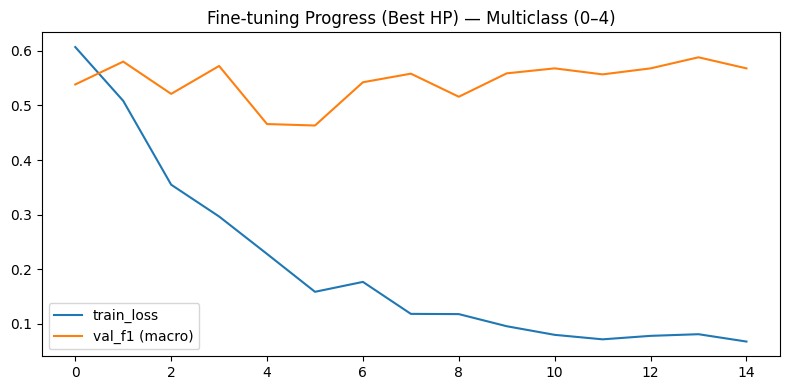

In [27]:
# Final training with best HP
hp = best["hp"]
finetune_model = make_finetune_model(cluster_model, NUM_CLASSES, dropout_p=hp["dropout"])
finetune_model.load_state_dict(best["state"])
criterion_sup = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(finetune_model.parameters(), lr=hp["lr"], weight_decay=hp["wd"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, FINAL_EPOCHS))

@torch.no_grad()
def evaluate_full(model, loader):
    model.eval()
    all_logits, all_y, all_ids = [], [], []
    for x, y, ids in loader:
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_y.append(y)
        all_ids += list(ids)
    all_logits = torch.cat(all_logits).numpy()
    all_y = torch.cat(all_y).numpy()
    preds = all_logits.argmax(1)
    acc = accuracy_score(all_y, preds)
    f1m = f1_score(all_y, preds, average='macro')
    return acc, f1m, preds, all_logits, all_y, all_ids

hist = {"train_loss": [], "val_f1": []}
best_val_f1, best_state = -1.0, None

for epoch in range(1, FINAL_EPOCHS + 1):
    finetune_model.train()
    total_loss, total = 0.0, 0
    # FIX 6: Use the new multiclass training loader for the final training run
    for x, y, _ in train_mc_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = finetune_model(x)
        loss = criterion_sup(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    scheduler.step()

    # FIX 7: Use the new multiclass validation loader for final training run
    val_acc, val_f1, _, _, _, _ = evaluate_full(finetune_model, val_mc_loader)
    tr_loss = total_loss / max(1, total)
    hist["train_loss"].append(tr_loss); hist["val_f1"].append(val_f1)
    print(f"[Final FT] {epoch:02d}/{FINAL_EPOCHS} | train_loss={tr_loss:.4f} | val_f1={val_f1:.4f} (acc={val_acc:.4f})")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state = copy.deepcopy(finetune_model.state_dict())

if best_state is not None:
    finetune_model.load_state_dict(best_state)

plt.figure(figsize=(8,4))
plt.plot(hist["train_loss"], label="train_loss")
plt.plot(hist["val_f1"], label="val_f1 (macro)")
plt.title("Fine-tuning Progress (Best HP) — Multiclass (0–4)")
plt.legend(); plt.tight_layout(); plt.show()

Test Accuracy: 0.7101 | Test F1 (macro): 0.5298

Classification Report (Test, 5 classes):
                   precision    recall  f1-score   support

        No DR (0)     0.8261    0.9500    0.8837        20
         Mild (1)     0.0000    0.0000    0.0000         4
     Moderate (2)     0.7200    0.7200    0.7200        25
       Severe (3)     0.5556    0.7692    0.6452        13
Proliferative (4)     0.6667    0.2857    0.4000         7

         accuracy                         0.7101        69
        macro avg     0.5537    0.5450    0.5298        69
     weighted avg     0.6726    0.7101    0.6792        69



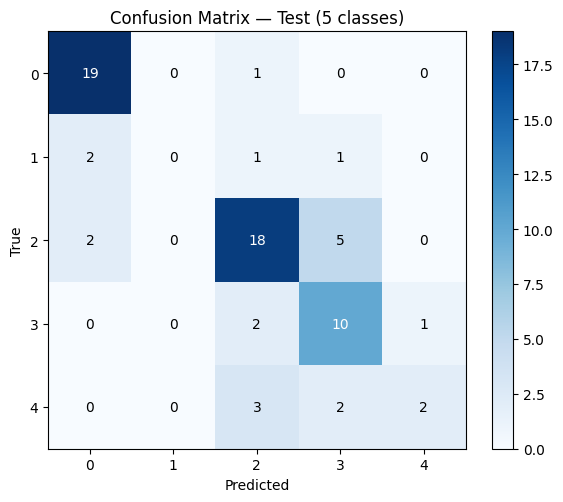

Macro ROC-AUC (OvR): 0.8462


In [28]:
# FIX 8: Use the new multiclass test loader for final evaluation
test_acc, test_f1, test_preds, test_logits, test_y, test_id = evaluate_full(finetune_model, test_mc_loader)
print(f"Test Accuracy: {test_acc:.4f} | Test F1 (macro): {test_f1:.4f}")

print("\nClassification Report (Test, 5 classes):")
target_names = ['No DR (0)','Mild (1)','Moderate (2)','Severe (3)','Proliferative (4)']
print(classification_report(test_y, test_preds, target_names=target_names, digits=4))

cm = confusion_matrix(test_y, test_preds, labels=list(range(NUM_CLASSES)))
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix — Test (5 classes)")
plt.colorbar()
plt.xticks(list(range(NUM_CLASSES)), list(range(NUM_CLASSES)))
plt.yticks(list(range(NUM_CLASSES)), list(range(NUM_CLASSES)))
plt.xlabel("Predicted"); plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout(); plt.show()

# (Optional) Macro ROC-AUC (OvR) for multiclass using probabilities
with torch.no_grad():
    probs = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

try:
    auc_macro_ovr = roc_auc_score(test_y, probs, multi_class='ovr', average='macro')
    print(f"Macro ROC-AUC (OvR): {auc_macro_ovr:.4f}")
except ValueError as e:
    print("ROC-AUC not defined (likely only one class present in y_test).", e)

## 11. Save Artifacts

In [ ]:

OUT = Path("./outputs")
OUT.mkdir(parents=True, exist_ok=True)
torch.save(finetune_model.state_dict(), OUT/"best_model_binary_dbscan.pth")

import json as _json
with open(OUT/"best_dbscan_params.json", "w") as f:
    _json.dump({"eps": float(best["eps"]), "min_samples": int(best["min_samples"])}, f, indent=2)

pd.DataFrame({"id_code": test_id, "true": test_y, "pred": test_preds}).to_csv(OUT/"test_predictions_binary_dbscan.csv", index=False)
print("Saved:", OUT/"best_model_binary_dbscan.pth", OUT/"best_dbscan_params.json", OUT/"test_predictions_binary_dbscan.csv")


## 12. Notes
- DBSCAN is sensitive to `eps` scale; we standardize + PCA to stabilize. Adjust `EPS_GRID` and `MIN_SAMPLES_GRID` if clusters look poor.
- Noise points (`-1`) are assigned using **nearest centroid** of non-noise clusters.
- You can also drop noise from pretraining by masking those indices if you want only high-confidence pseudo-labels.
- For screening, consider threshold tuning on validation for higher sensitivity (recall) on class 1.


In [ ]:
# 5-class evaluation
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Assuming y_true and y_pred exist (y_pred are integer class IDs 0..4)
print(classification_report(y_true, y_pred, labels=[0,1,2,3,4], digits=4))

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3,4])
print("Confusion matrix (rows=true, cols=pred):\n", cm)

# Simple matplotlib heatmap (no seaborn)
fig = plt.figure()
ax = plt.gca()
im = ax.imshow(cm, interpolation='nearest')
ax.set_title('Confusion Matrix (0–4)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_xticks(range(5)); ax.set_yticks(range(5))
ax.set_xticklabels([0,1,2,3,4]); ax.set_yticklabels([0,1,2,3,4])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar(im)
plt.show()